# EE-411 — Fundamentals of Inference and Learning
## Exercise Session 2 — The lighthouse problem

Use SciPy to locate a lighthouse from the positions where its flashes reach the shore.

**Learning objectives**
- Generate Cauchy-distributed observations with SciPy.
- Estimate one or two unknown parameters by maximizing a likelihood.
- Compare estimators using mean squared error and the Cramér–Rao bound.
- Use a prior and bootstrap confidence intervals to interpret an estimate.

**Prerequisites**
- Probability densities, likelihood, and basic Python functions, arrays, and plots.
- Python packages: NumPy, SciPy, Matplotlib, and tqdm (for the solution's progress bars).
- The supplied `where_is_the_light.npy` file, kept in the same folder as this notebook. Run the notebook from the TP2 folder.

**How to work through this notebook**
Run the provided worked examples in order. Complete the cells marked `TODO` / `YOUR CODE HERE` and write your explanations in the corresponding answer cells.

## Part 1 — Locating the lighthouse

**Locating the lighthouse**

A lighthouse is located somewhere off a piece of straight coastline at a position $\alpha$ (or $x_0$) along the shore and a distance $\beta$ (or $y_0$) out at sea. It emits a series of short highly collimated flashes at random intervals and hence at random azimuths. These pulses are intercepted on the coast by photo-detectors that record only the fact that a flash has occurred, but not the angle from which it came. N flashes have so far been recorded at positions $\{x_k\}$. Where is the lighthouse?’ (from D. Sivia's book, "Data Analysis - A Bayesian Tutorial")

[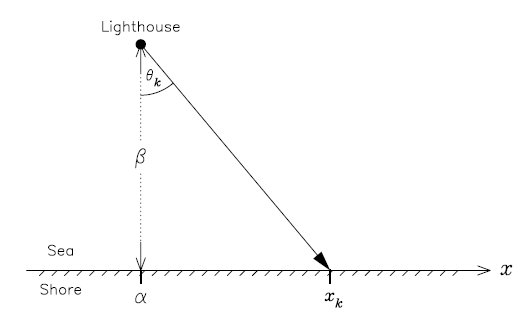](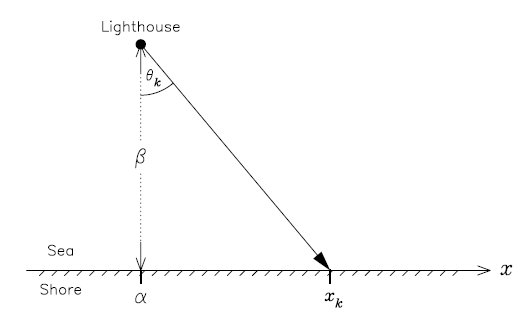)



### Exercise 1 — Derive the flash-position density

Compute the probability density $p(x\mid x_0,y_0)$ for a flash arriving at position $x$ along the shore, where $x_0$ is the lighthouse's position along the shore and $y_0>0$ is its distance from the shore. Assume the direction of a flash reaching the shore is uniform over $(-\pi/2,\pi/2)$.

Show the relation between the angle and the arrival position, then use a change of variables to obtain the density. Write your derivation below before continuing to the provided example.

**Solution:**

From the previous description, we know that the angle $\theta$ is uniform over $(- \pi/2, \pi/2)$, therefore we have

$$p(\theta|x_0,y_0) = \frac{1}{\pi}$$

The position $x$ is given by 

$$x = y_0 \tan \theta + x_0$$

Using the relation $p(x)dx = p(\theta)d\theta$ we can compute

$$p(x|x_0,y_0) = p(\theta|x_0,y_0)\bigg|\frac{d\theta}{dx}\bigg|$$

Since $x = y_0 \tan \theta + x_0$, if we differentiate $\theta$ with respect to $x$ we get:

$$\frac{d\theta}{dx} = \frac{d}{dx}\bigg( \arctan\frac{x-x_0}{y_0} \bigg) = \frac{1}{y_0\Big( 1 + \big(\frac{x-x_0}{y_0}\big)^2\Big)} = \frac{y_0}{(x-x_0)^2 + y_0^2}>0$$

Getting back to $p(x|x_0,y_0)$:

$$p(x | x_0,y_0) = p(\theta | x_0,y_0) \left| \frac{d\theta}{dx} \right| = \frac{1}{\pi} \frac{y_0}{(x-x_0)^2 + y_0^2}$$

which is the **Cauchy distribution** with parameters $x_0$ and $y_0$.

### Recall — Maximum likelihood estimation

Assume that the data comes from a true probability distribution $x \sim P_{\lambda^{\star}}(x) = P(x|\lambda^{\star})$ for some unknown parameter $\lambda^{\star}.$
The maximum likelihood estimator gives us the parameter $\lambda$ of the distribution $P(\cdot|\lambda)$ that makes the observation of a given set of data $\{x_i\}$ most likely . Assuming that the observations are independent, and that the probability of observing $x$ is given by the probability distribution $P(x|\lambda)$
$$
\widehat{\lambda}_{ML}=argmax_{\lambda}\prod_i P(x_i|\lambda)=argmax_{\lambda}\left(\sum_i\log(P(x_i|\lambda))\right)
$$

There are two additional quantities that will be important for our purpose. The first one is called the score
$$
S(x,\lambda)=\partial_\lambda L(x|\lambda),
$$
where we introduce the log-likelihood $L(x|\lambda)=\log P(x|\lambda)$. Importantly, the expectation of the score with respect to $P(x|\lambda)$ is zero, that is, $\mathbb{E}_{\lambda}[S(x,\lambda)]=0$. The second one is the Fisher information, which corresponds to the variance of the score when data are sampled at parameter $\lambda$:
$$
I(\lambda)=\mathbb{E}_{\lambda}[S(x|\lambda)^2].
$$
In case of $N$ independent events, we simply have
$$
I_N(\lambda)=\sum_{i=1}^N I(\lambda) = NI(\lambda).
$$

### Provided example — Estimate distance with a known position

We generate observations with $x_0=20$ and $y_0=15$, then estimate $y_0$ while treating $x_0$ as known.

The following worked example provides the density from Exercise 1 and the code to use it. Run it after attempting your derivation.

Then, we wish to find

$$p(y_0 | \{x_k\}, x_0)$$

Using Bayes’ theorem:

$$p(y_0 | \{x_k\}, x_0) = \frac{p(y_0 , \{x_k\}, x_0)}{p(\{x_k\}, x_0)} = \frac{p(\{x_k\} | y_0, x_0)p(y_0 | x_0)p(x_0)}{p(\{x_k\} | x_0)p(x_0)}\propto p(\{x_k\} | y_0, x_0) p(y_0)$$

where the last step uses the prior assumption that  $y_0 \perp x_0$, and so we have $p(y_0 | x_0) = p(y_0)$.
The most intuitive prior $p(y_0)$ when we don't have additional information is the one which is uniform over a large enough segment $[y_{min}, y_{max}]$, i.e. $p(y_0) = 1/(y_{max}-y_{min})$

Even if this seems to be a good choice in general, we will compare it with another prior below.
For the data likelihood $p(\{x_k\} | y_0, x_0)$ we consider that the observations $x_k$ are independent and identically distributed (i.i.d.), so:

$$p(\{x_k\} | y_0, x_0) = \prod_{k=1}^N p(x_k | y_0, x_0)$$

Within the uniform prior's support, we get:

$$p(y_0 | \{x_k\}, x_0) \propto \prod_{k=1}^N p(x_k | y_0, x_0)$$

If the likelihood maximum lies within that support, maximizing the posterior coincides with maximizing the log-likelihood $L(\{x_k\} | x_0,y_0)$

We generate $N=100$ flashes and plot the log-likelihood as a function of $y_0$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import cauchy
from scipy.optimize import minimize

np.random.seed(123456)  # Reproduce the simulations when running all cells in order.

Define `loglh` to compute the log-likelihood for observations `x`, given the position `x0` and positive distance `y0`.

In [2]:
def loglh(x0, y0, x):
    if y0 <= 0:
        return -np.inf
    return np.sum(np.log(y0) - np.log(np.pi) - np.log(y0**2 + (x - x0)**2))

Generate observations from the Cauchy distribution using `scipy.stats.cauchy`. Its location is $x_0$ and its scale is $y_0$.

In [3]:
N = 100
x0_true = 20
y0_true = 15

x = cauchy.rvs(loc=x0_true, scale=y0_true, size=N)

Compute the log-likelihood for a range of positive distances around the true value $y_0^*$ and plot it.

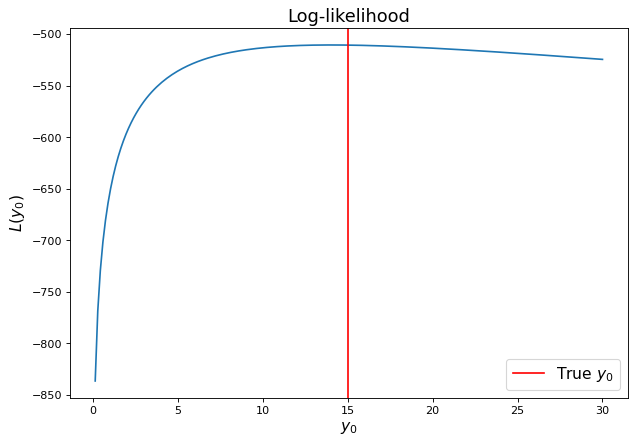

In [4]:
tab_y0 = np.linspace(0, 2 * y0_true, 200)[1:]
logl_y0 = np.array([loglh(x0_true, y0, x) for y0 in tab_y0])

fig = plt.figure(figsize=(9, 6), dpi=80)
plt.title('Log-likelihood', fontsize=16)
plt.xlabel(r'$y_0$', fontsize=14)
plt.ylabel(r'$L(y_0)$', fontsize=14)
plt.plot(tab_y0, logl_y0)
plt.axvline(y0_true, color='r', label=r'True $y_0$')
plt.legend(fontsize=14);

To display the same curve on a relative-likelihood scale, plot $\exp(L-L_{\max})$. Subtracting the maximum keeps the values numerically manageable.

Under a uniform prior, this has the shape of the posterior within the prior's support. Its maximum is one; it is not a normalized probability density.

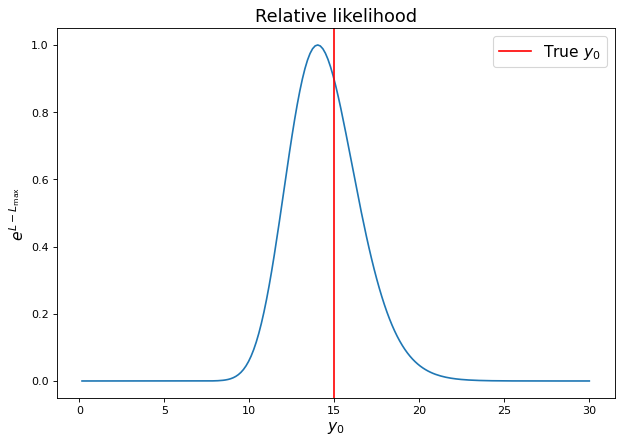

In [5]:
fig = plt.figure(figsize=(9, 6), dpi=80)
plt.title('Relative likelihood', fontsize=16)
plt.xlabel(r'$y_0$', fontsize=14)
plt.ylabel(r'$e^{L-L_{\max}}$', fontsize=14)
plt.plot(tab_y0, np.exp(logl_y0 - logl_y0.max()))
plt.axvline(y0_true, color='r', label=r'True $y_0$')
plt.legend(fontsize=14);

Next, compute the maximum likelihood estimate $\widehat{y}_{0,ML}$ for several sample sizes and compare it with the true distance.

Use `scipy.optimize.minimize` to minimize the negative log-likelihood. To keep the distance positive, optimize `log_y0` and recover `y0 = np.exp(log_y0)`. We still evaluate the same likelihood at that distance.

The provided `checked_minimize` helper checks that the optimizer has converged before its result is used.

In [6]:
%%time

def checked_minimize(objective, initial_guess, bounds=None):
    result = minimize(objective, initial_guess, method='Nelder-Mead', bounds=bounds)
    if not result.success or not np.isfinite(result.fun) or not np.all(np.isfinite(result.x)):
        raise RuntimeError(f'Optimization failed: {result.message}')
    return result.x

tab_N = np.unique(np.logspace(0, 4, num=10).astype(int))
y0_ML = []
for N in tab_N:
    x = cauchy.rvs(loc=x0_true, scale=y0_true, size=N)
    y0_guess = np.median(np.abs(x - x0_true))
    log_y0 = checked_minimize(
        lambda params: -loglh(x0_true, np.exp(params[0]), x),
        [np.log(y0_guess)],
    )[0]
    y0_ML.append(np.exp(log_y0))

CPU times: user 5.65 ms, sys: 1.42 ms, total: 7.07 ms
Wall time: 7.08 ms


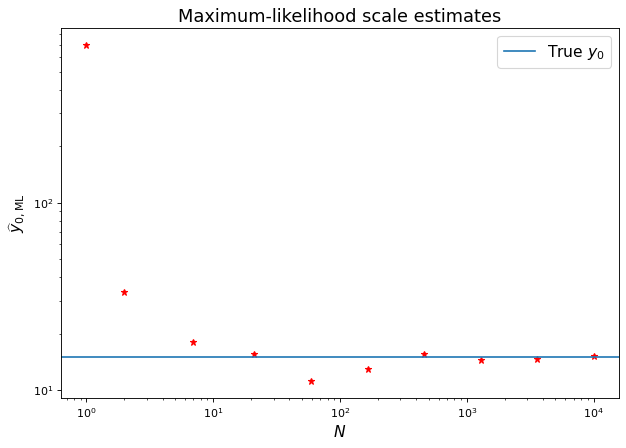

In [7]:
fig = plt.figure(figsize=(9, 6), dpi=80)
plt.title('Maximum-likelihood scale estimates', fontsize=16)
plt.xlabel(r'$N$', fontsize=14)
plt.ylabel(r'$\widehat{y}_{0,\mathrm{ML}}$', fontsize=14)
plt.plot(tab_N, y0_ML, '*', color='r')
plt.axhline(y0_true, label=r'True $y_0$')
plt.xscale('log')
plt.yscale('log')
plt.legend(fontsize=14);

### Exercise 2 — Estimate position with a known distance

Now treat $y_0=15$ as known and estimate $x_0$. Use $x_0=20$ to generate the simulated data.

1. Generate $N=100$ Cauchy-distributed flashes.
2. Plot the log-likelihood over positions around the true value. Optionally, also plot the relative likelihood $\exp(L-L_{\max})$.
3. Estimate $x_0$ for logarithmically spaced integer sample sizes from $1$ to $10^4$ and plot the estimates against $N$.
4. Compare the estimates with the true position and describe how their variability changes with $N$.

Reuse `loglh` and `checked_minimize` from the provided example.

In [8]:
# TODO: Generate 100 Cauchy-distributed flashes for the known-distance experiment.

# YOUR CODE HERE

In [9]:
# TODO: Compute and plot the log-likelihood as a function of position.

# YOUR CODE HERE

In [10]:
# TODO: Optionally plot the relative likelihood as a function of position.

# YOUR CODE HERE

In [11]:
# TODO: Fit the position for integer sample sizes from 1 to 10**4.

# YOUR CODE HERE

In [12]:
# TODO: Plot the fitted positions against sample size and mark the true position.

# YOUR CODE HERE

**Your answer:** Describe the position estimates as the sample size increases.

*Write your answer here.*

### Exercise 3 — Compare the sample mean and median

Use the same true position and distance as before.

1. Generate samples for logarithmically spaced integer sizes from $1$ to $10^7$. Compute and plot the sample mean against $N$.
2. Repeat with the sample median for sizes from $1$ to $10^4$; this smaller range is sufficient to see its behaviour.
3. Explain which estimate settles near $x_0=20$ as the sample grows. Relate your observation to the Cauchy distribution.

In [13]:
# TODO: Generate samples up to size 10**7 and compute their sample means.

# YOUR CODE HERE

In [14]:
# TODO: Plot the sample means against sample size.

# YOUR CODE HERE

**Your answer:** Explain the behaviour of the sample mean.

*Write your answer here.*

Next, repeat the simulation using the sample median.

In [15]:
# TODO: Generate samples up to size 10**4 and compute their sample medians.

# YOUR CODE HERE

In [16]:
# TODO: Plot the sample medians and mark the true position.

# YOUR CODE HERE

**Your answer:** Compare the sample mean and median as position estimators.

*Write your answer here.*

Next we use mean squared error to compare the median with maximum likelihood estimation.

## Part 2 — Comparing estimators

**Mean squared error (MSE)** is the expected squared difference between an estimator and the true parameter:

$$\mathrm{MSE}(\widehat{\lambda};\lambda)=\mathbb{E}_{\lambda}\left[(\widehat{\lambda}-\lambda)^2\right].$$

The expectation is over repeated datasets generated with the same true parameter $\lambda$. We approximate it by repeating the simulation.

### Recall — Fisher information

As we recalled earlier, for $N$ independent events we have
$$
I_N(\lambda)=\sum_{i=1}^N I(\lambda) = NI(\lambda).
$$

Therefore for our problem

$$
I_N(x_0, y_0) = -N \mathbb{E}_x\begin{bmatrix}\frac{\partial^2 L}{\partial x_0^2} & \frac{\partial^2 L}{\partial x_0\partial y_0}\\ \frac{\partial^2 L}{\partial y_0\partial x_0} & \frac{\partial^2 L}{\partial y_0^2}\end{bmatrix}
$$

And after a bit of computations, and a little help from [Wolfram Alpha](https://www.wolframalpha.com/calculators/integral-calculator/), one finds that if $x \in(-\infty,+\infty)$ then the Fisher information is

$$I_N(x_0, y_0) =\begin{bmatrix}\frac{N}{2y_0^2} & 0\\0 & \frac{N}{2y_0^2}\end{bmatrix} = \frac{N}{2y_0^2} \mathbb{I}_2$$

And therefore

*   $\det [I_N(x_0,y_0)] = \frac{N^2}{4y_0^4}$
*   $I_N(y_0|x_0) = \frac{N}{2y_0^2}$
*   $I_N(x_0|y_0) = \frac{N}{2y_0^2} = \text{constant in }x_0$

### Recall — Cramér–Rao bound

For an **unbiased estimator**, the Cramér–Rao bound gives

$$\mathrm{MSE}(\widehat{\lambda}_i;\lambda_i)\geq\{[I_N(\boldsymbol{\lambda})]^{-1}\}_{ii}.$$

Maximum likelihood and maximum a posteriori estimators need not be unbiased for small samples. We use this bound as a reference when comparing them; a biased estimator can have MSE below the unbiased-estimator bound.

### Recall — Jeffreys prior

In general, the Jeffreys prior is given by

$$p(\mathbf{\lambda}) \propto \sqrt{\det[I_N(\mathbf{\lambda})]}$$

### Provided example — Compare distance estimates

Treat $x_0=20$ as known and estimate $y_0$. For an unbiased estimator of the distance, the Cramér–Rao bound is

$$\mathrm{MSE}(\widehat{y}_0;y_0)\geq\frac{2y_0^2}{N}.$$

The one-parameter Jeffreys prior is $p(y_0)\propto1/y_0$. Thus

$$p(y_0\mid\{x_k\},x_0)\propto\frac{1}{y_0}\prod_{k=1}^N\frac{1}{\pi}\frac{y_0}{(x_k-x_0)^2+y_0^2}.$$

Maximizing this posterior gives the **maximum a posteriori (MAP)** estimate. We only need the posterior up to proportionality for this calculation.

Compute the MSE of the ML and MAP distance estimators and compare them with the Cramér–Rao reference.

First, define `jeffpost`, the log-posterior up to an additive constant for the prior proportional to `1 / y0`.

In [17]:
def jeffpost(x0, y0, x):
    if y0 <= 0:
        return -np.inf
    return loglh(x0, y0, x) - np.log(y0)

The provided `minimizer_y0` helper simulates repeated datasets and estimates the distance. Its arguments specify the known position, sample size, and number of repetitions.

In [18]:
def minimizer_y0(func, y0, x0, N, N_rep):
    y0_est = np.zeros(N_rep)
    for ir in range(N_rep):
        x = cauchy.rvs(loc=x0, scale=y0, size=N)
        y0_guess = np.median(np.abs(x - x0))
        log_y0 = checked_minimize(
            lambda params: -func(x0, np.exp(params[0]), x),
            [np.log(y0_guess)],
        )[0]
        y0_est[ir] = np.exp(log_y0)
    return y0_est

To estimate MSE, repeat each fit $N_{rep}=500$ times, with $N=10$ flashes per dataset, for $N_{est}=15$ true distances in $(0,1]$.

In [19]:
N_est=15
tab_y0=np.linspace(0,1,N_est+1)[1:]
N = 10
N_rep = 500

In [20]:
%%time

y0_ML = np.array([minimizer_y0(loglh, y0, x0_true, N, N_rep) for y0 in tab_y0])
y0_J = np.array([minimizer_y0(jeffpost, y0, x0_true, N, N_rep) for y0 in tab_y0])

CPU times: user 4 s, sys: 61.1 ms, total: 4.06 s
Wall time: 4.07 s


For each true distance, average the squared errors over the repeated fits. Bootstrap these squared errors to describe uncertainty from the finite number of simulation repetitions.

The provided `MSE_est` helper returns the empirical MSE and the 2.5th and 97.5th percentiles of its bootstrap estimates. These intervals concern the simulated MSE; the final exercise instead bootstraps the observed flashes to obtain intervals for the fitted parameters.

In [21]:
def MSE_est(estimates, true_value, N_boot=100):
    squared_errors = (np.asarray(estimates) - true_value)**2
    mse = squared_errors.mean()
    bootstrap_errors = np.random.choice(
        squared_errors, size=(N_boot, len(squared_errors)), replace=True
    )
    bootstrap_means = bootstrap_errors.mean(axis=1)
    ci_min, ci_max = np.percentile(bootstrap_means, [2.5, 97.5])
    return mse, ci_min, ci_max

Compute the empirical MSE and bootstrap interval for each true distance.

In [22]:
MSE_ML_10 = np.zeros(N_est)
CI_min_ML_10 = np.zeros(N_est)
CI_max_ML_10 = np.zeros(N_est)
MSE_J_10 = np.zeros(N_est)
CI_min_J_10 = np.zeros(N_est)
CI_max_J_10 = np.zeros(N_est)

for j,y0 in enumerate(tab_y0):
  MSE, CI_min, CI_max = MSE_est(y0_ML[j], y0)
  MSE_ML_10[j] = MSE
  CI_min_ML_10[j] = CI_min
  CI_max_ML_10[j] = CI_max
  MSE, CI_min, CI_max = MSE_est(y0_J[j], y0)
  MSE_J_10[j] = MSE
  CI_min_J_10[j] = CI_min
  CI_max_J_10[j] = CI_max

Plot the empirical MSEs and bootstrap intervals alongside the Cramér–Rao reference.

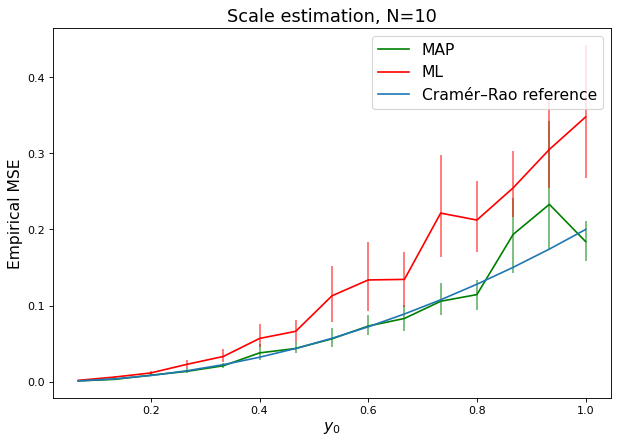

In [23]:
def plot_mse_interval(parameters, mse, ci_min, ci_max, color, label):
    plt.plot(parameters, mse, color=color, label=label)
    plt.vlines(parameters, ci_min, ci_max, color=color, alpha=0.6)

fig = plt.figure(figsize=(9, 6), dpi=80)
plt.title(f'Scale estimation, N={N}', fontsize=16)
plt.xlabel(r'$y_0$', fontsize=14)
plt.ylabel('Empirical MSE', fontsize=14)
plot_mse_interval(tab_y0, MSE_J_10, CI_min_J_10, CI_max_J_10, 'g', 'MAP')
plot_mse_interval(tab_y0, MSE_ML_10, CI_min_ML_10, CI_max_ML_10, 'r', 'ML')
plt.plot(tab_y0, 2 * tab_y0**2 / N, label='Cramér–Rao reference')
plt.legend(fontsize=14);

### Exercise 4 — Vary the number of flashes

Repeat the preceding distance-estimation experiment with $N=3$ and $N=50$, keeping $x_0=20$ known. Use 1,000 repetitions for $N=3$ and 200 for $N=50$.

Plot the ML and MAP empirical MSEs and bootstrap intervals for $N=3,10,50$ together with the corresponding Cramér–Rao references. Describe how the results change with $N$. For very small samples, pay attention to the stability of simulation averages.

In [24]:
# TODO: Repeat the distance MSE experiment for N = 3 with 1,000 repetitions.

# YOUR CODE HERE

In [25]:
# TODO: Repeat the distance MSE experiment for N = 50 with 200 repetitions.

# YOUR CODE HERE

In [26]:
# TODO: Plot the ML and MAP MSEs, intervals, and references for N = 3, 10, 50.

# YOUR CODE HERE

**Your answer:** Interpret the ML/MAP comparison across sample sizes.

*Write your answer here.*

### Exercise 5 — Compare position estimates

Treat $y_0=15$ as known and consider true positions $x_0\in[-1,1]$.

1. What does the one-parameter Jeffreys prior give for $x_0$? What does this imply for ML and MAP position estimates?
2. Start with $N=10$ and 500 repetitions. Compare the empirical MSE of the ML and sample-median estimators across the true positions, and plot their bootstrap intervals and the Cramér–Rao reference.
3. Repeat for $N=3$ with 1,000 repetitions and $N=50$ with 200 repetitions. Plot all three sample sizes together and interpret the comparison.

**Your answer:** Explain the Jeffreys prior for position when the distance is known.

*Write your answer here.*

Define helpers that simulate datasets and return repeated ML and sample-median position estimates.

In [27]:
# TODO: Define helpers for repeated ML and sample-median position estimates.

# YOUR CODE HERE

Start with $N=10$ and compute the empirical MSEs and bootstrap intervals.

In [28]:
# TODO: Set a true-position grid in [-1, 1], N = 10, and 500 repetitions.

# YOUR CODE HERE

In [29]:
# TODO: Compute repeated ML and sample-median estimates for each true position.

# YOUR CODE HERE

In [30]:
# TODO: Compute the MSEs and bootstrap intervals for N = 10.

# YOUR CODE HERE

In [31]:
# TODO: Plot both MSEs and their intervals with the Cramér–Rao reference.

# YOUR CODE HERE

Repeat for $N=3$ and $N=50$, then compare all three sample sizes with the Cramér–Rao references.

In [32]:
# TODO: Set N = 3 and 1,000 repetitions.

# YOUR CODE HERE

In [33]:
# TODO: Repeat the ML and median position estimates for N = 3.

# YOUR CODE HERE

In [34]:
# TODO: Compute the MSEs and bootstrap intervals for N = 3.

# YOUR CODE HERE

In [35]:
# TODO: Set N = 50 and 200 repetitions.

# YOUR CODE HERE

In [36]:
# TODO: Repeat the ML and median position estimates for N = 50.

# YOUR CODE HERE

In [37]:
# TODO: Compute the MSEs and bootstrap intervals for N = 50.

# YOUR CODE HERE

In [38]:
# TODO: Plot and compare position-estimation MSEs for N = 3, 10, 50.

# YOUR CODE HERE

**Your answer:** Interpret the ML/median comparison across sample sizes.

*Write your answer here.*

## Part 3 — Estimating both parameters

### Provided example — Fit position and distance together

Return to $x_0=20$ and $y_0=15$ for data generation, and now treat both parameters as unknown during fitting.

With independent uniform priors over sufficiently broad fixed intervals, the posterior is proportional to the likelihood within those intervals:

$$p(x_0,y_0\mid\{x_k\})\propto p(\{x_k\}\mid x_0,y_0).$$

Generate $N=100$ flashes and plot the log-likelihood and relative likelihood as functions of both position and distance.

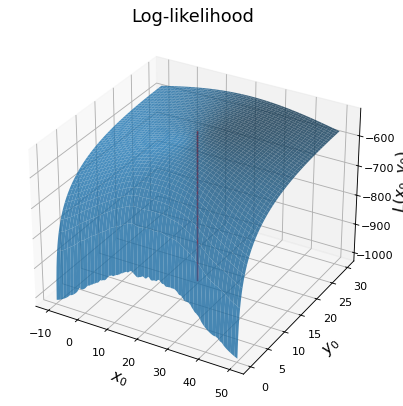

In [39]:
x0_true = 20
y0_true = 15
N = 100
tab_y0 = np.linspace(0, 2 * y0_true, 201)[1:]
tab_x0 = np.linspace(x0_true - 2 * y0_true, x0_true + 2 * y0_true, 200)
x = cauchy.rvs(loc=x0_true, scale=y0_true, size=N)

X, Y = np.meshgrid(tab_x0, tab_y0)
Z = np.array([[loglh(x0, y0, x) for x0 in tab_x0] for y0 in tab_y0])

fig = plt.figure(figsize=(9, 6), dpi=80)
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Log-likelihood', fontsize=16)
ax.plot_surface(X, Y, Z, alpha=0.8)
ax.plot([x0_true, x0_true], [y0_true, y0_true], [Z.min(), Z.max()], color='r')
ax.set_xlabel(r'$x_0$', fontsize=14)
ax.set_ylabel(r'$y_0$', fontsize=14)
ax.set_zlabel(r'$L(x_0, y_0)$', fontsize=14)
plt.show()

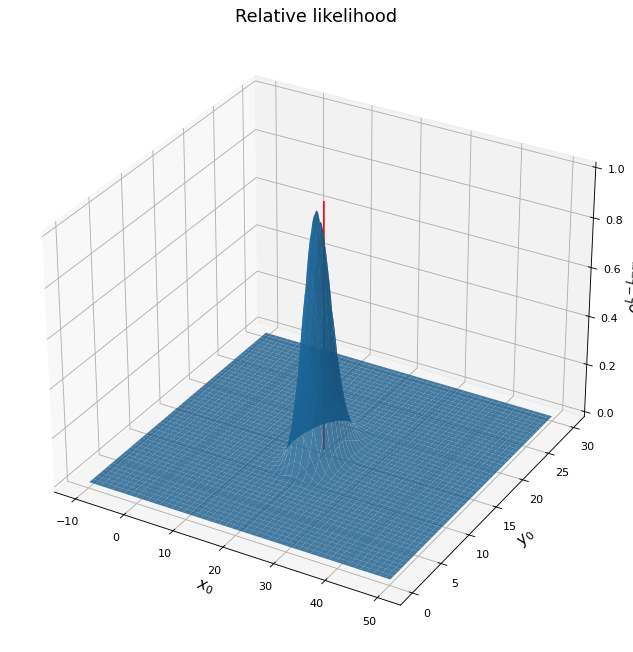

In [40]:
relative_likelihood = np.exp(Z - Z.max())

fig = plt.figure(figsize=(12, 10), dpi=80)
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Relative likelihood', fontsize=16)
ax.plot_surface(X, Y, relative_likelihood, alpha=0.8)
ax.plot([x0_true, x0_true], [y0_true, y0_true], [0, 1], color='r')
ax.set_xlabel(r'$x_0$', fontsize=14)
ax.set_ylabel(r'$y_0$', fontsize=14)
ax.set_zlabel(r'$e^{L-L_{\max}}$', fontsize=14)
plt.show()

Finally, fit both parameters for increasing sample sizes. As before, optimize the log-distance to keep the distance positive.

Start with at least three flashes: one flash has no finite joint maximum-likelihood estimate, and two flashes do not give a unique one.

In [41]:
%%time

def fit_parameters(x, func=loglh, x0_bounds=None, y0_max=None):
    x0_guess = np.median(x)
    if x0_bounds is None:
        x0_bounds = (None, None)
    else:
        x0_guess = np.clip(x0_guess, x0_bounds[0], x0_bounds[1])
    y0_guess = np.median(np.abs(x - x0_guess))
    if y0_max is not None:
        y0_guess = min(y0_guess, y0_max)
    log_y0_max = None if y0_max is None else np.log(y0_max)
    if y0_guess <= 0:
        raise ValueError('The observations must give a positive initial scale.')
    params = checked_minimize(
        lambda params: -func(params[0], np.exp(params[1]), x),
        [x0_guess, np.log(y0_guess)],
        bounds=[x0_bounds, (None, log_y0_max)],
    )
    return np.array([params[0], np.exp(params[1])])

# Joint estimation uses N >= 3 to avoid the degenerate one- and two-sample cases.
tab_N = np.unique(np.geomspace(3, 10_000, num=20).astype(int))
x0_ML = []
y0_ML = []
for N in tab_N:
    x = cauchy.rvs(loc=x0_true, scale=y0_true, size=N)
    x0_estimate, y0_estimate = fit_parameters(x)
    x0_ML.append(x0_estimate)
    y0_ML.append(y0_estimate)

CPU times: user 33.1 ms, sys: 6.66 ms, total: 39.8 ms
Wall time: 37.9 ms


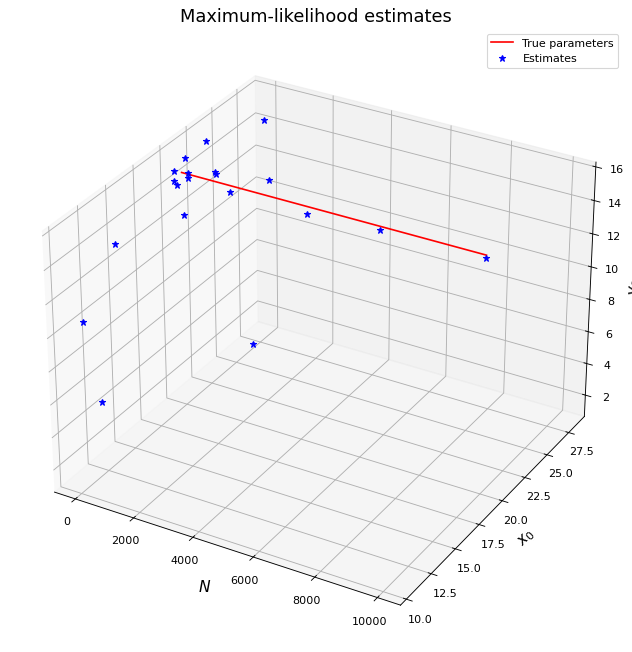

In [42]:
fig = plt.figure(figsize=(12, 10), dpi=80)
ax = fig.add_subplot(111, projection='3d')
ax.set_title('Maximum-likelihood estimates', fontsize=16)
ax.plot([tab_N.min(), tab_N.max()], [x0_true, x0_true], [y0_true, y0_true],
        color='r', label='True parameters')
ax.plot(tab_N, x0_ML, y0_ML, marker='*', color='b', ls='None', label='Estimates')
ax.set_xlabel(r'$N$', fontsize=14)
ax.set_ylabel(r'$x_0$', fontsize=14)
ax.set_zlabel(r'$y_0$', fontsize=14)
ax.legend()
plt.show()

### Exercise 6 — Locate an unknown lighthouse (assessed)

Load the supplied `where_is_the_light.npy` file into a NumPy array and determine the sample size from the array.

1. Estimate $x_0$ and $y_0$ by maximum likelihood. You know that $x_0\in[-100,100]$ and $0<y_0\leq30$; respect these ranges in the fit.
2. Resample the observed flashes with replacement, refit both parameters, and use 1,000 bootstrap repetitions to obtain a **95% confidence interval for each parameter**.
3. Report both point estimates and intervals, and briefly interpret the uncertainty in the lighthouse's location.

**Bonus — Compare prior choices.** Repeat the fit and bootstrap calculation with independent priors: a uniform prior for $x_0$ on the stated interval and $p(y_0)\propto1/y_0$ on the stated distance range. This combines the one-parameter Jeffreys choice for distance with a separate flat position prior.

Compare the resulting estimates and intervals with ML (or MAP under uniform priors). Can this single dataset, whose true parameters are unknown, establish which estimator has smaller MSE?

In [43]:
# TODO: Load where_is_the_light.npy and determine the number of flashes.

# YOUR CODE HERE

In [44]:
# TODO: Fit the position and distance within the given ranges; optionally repeat with the independent prior.

# YOUR CODE HERE

In [45]:
# TODO: Bootstrap the fitted parameters and report their 95% intervals; optionally repeat for MAP.

# YOUR CODE HERE

**Your answer:** Interpret the parameter intervals and answer the prior-comparison bonus if attempted.

*Write your answer here.*